In [7]:
# ============================================
# CELL 1: ENVIRONMENT + CONFIGURATION
# ============================================

import os
import random
import numpy as np

import torch
import torch.nn as nn
import torchvision
import torchvision.models as models

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# ============================================
# 1. REPRODUCIBILITY
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================
# 2. DEVICE
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================
# 3. IMAGE CONFIGURATION
# ============================================

IMAGE_SIZE = 224
NUM_CLASSES = 4


# ============================================
# 4. TRAINING CONFIGURATION
# ============================================

BATCH_SIZE = 16
EPOCHS = 20


# ============================================
# 5. IMAGENET NORMALIZATION
# ============================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ============================================
# 6. DATASET PATHS
# ============================================

from pathlib import Path

# Repo root: walk up from the notebook's directory until app.py is found.
BASE_PATH = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "app.py").is_file())

KAGGLE_PATH = (
    BASE_PATH / "datasets" / "KAGGLE DATASET"
    / "Combined Dataset" / "train"
)

MODELS_PATH = BASE_PATH / "models"

RESULTS_PATH = BASE_PATH / "results"


# ============================================
# 7. CREATE DIRECTORIES
# ============================================

os.makedirs(
    MODELS_PATH,
    exist_ok=True
)

os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)


# ============================================
# 8. DISPLAY CONFIGURATION
# ============================================

print("=" * 60)
print("ENVIRONMENT CONFIGURATION")
print("=" * 60)

print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")

print(f"CUDA available      : {torch.cuda.is_available()}")

print(f"Device              : {device}")

if torch.cuda.is_available():

    print(
        f"CUDA version        : {torch.version.cuda}"
    )

    print(
        f"GPU                 : "
        f"{torch.cuda.get_device_name(0)}"
    )

    gpu_memory = (
        torch.cuda.get_device_properties(0)
        .total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU memory          : "
        f"{gpu_memory:.2f} GB"
    )

print("\n" + "-" * 60)

print(f"Image size          : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Number of classes   : {NUM_CLASSES}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Epochs              : {EPOCHS}")

print("\n" + "-" * 60)

print("ImageNet Mean:")
print(IMAGENET_MEAN)

print("\nImageNet Std:")
print(IMAGENET_STD)

print("\n" + "-" * 60)

print("Dataset path:")
print(KAGGLE_PATH)

print("\nModels path:")
print(MODELS_PATH)

print("\nResults path:")
print(RESULTS_PATH)

print("=" * 60)

ENVIRONMENT CONFIGURATION
PyTorch version     : 2.0.1+cu118
Torchvision version : 0.15.2+cu118
CUDA available      : True
Device              : cuda
CUDA version        : 11.8
GPU                 : NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory          : 4.00 GB

------------------------------------------------------------
Image size          : 224 x 224
Number of classes   : 4
Batch size          : 16
Epochs              : 20

------------------------------------------------------------
ImageNet Mean:
[0.485, 0.456, 0.406]

ImageNet Std:
[0.229, 0.224, 0.225]

------------------------------------------------------------
Dataset path:
datasets\KAGGLE DATASET\Combined Dataset\train

Models path:
models

Results path:
results


In [8]:
# ============================================
# CELL 2: DATASET + TRANSFORMS
# ============================================


# ============================================
# 1. TRAINING TRANSFORM
# ============================================

train_transform = transforms.Compose([

    # Resize every image to 224 x 224
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    # Convert grayscale image to 3 channels
    transforms.Grayscale(
        num_output_channels=3
    ),

    # Training augmentation
    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================
# 2. VALIDATION / TEST TRANSFORM
# ============================================

eval_transform = transforms.Compose([

    # Resize
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    # Convert grayscale to 3 channels
    transforms.Grayscale(
        num_output_channels=3
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================
# 3. LOAD DATASET
# ============================================

base_dataset = datasets.ImageFolder(
    root=KAGGLE_PATH
)


# ============================================
# 4. DATASET SIZE
# ============================================

total_size = len(base_dataset)

train_size = int(
    0.70 * total_size
)

val_size = int(
    0.15 * total_size
)

test_size = (
    total_size
    - train_size
    - val_size
)


# ============================================
# 5. REPRODUCIBLE SPLIT
# ============================================

generator = torch.Generator().manual_seed(
    SEED
)

train_indices, val_indices, test_indices = (
    random_split(
        range(total_size),
        [
            train_size,
            val_size,
            test_size
        ],
        generator=generator
    )
)


# ============================================
# 6. TRAINING DATASET
# ============================================

train_dataset_full = datasets.ImageFolder(
    root=KAGGLE_PATH,
    transform=train_transform
)


# ============================================
# 7. VALIDATION / TEST DATASET
# ============================================

eval_dataset = datasets.ImageFolder(
    root=KAGGLE_PATH,
    transform=eval_transform
)


# ============================================
# 8. CREATE SUBSETS
# ============================================

train_data = torch.utils.data.Subset(
    train_dataset_full,
    train_indices.indices
)

val_data = torch.utils.data.Subset(
    eval_dataset,
    val_indices.indices
)

test_data = torch.utils.data.Subset(
    eval_dataset,
    test_indices.indices
)


# ============================================
# 9. DISPLAY DATASET INFORMATION
# ============================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(
    f"Total images      : {total_size}"
)

print(
    f"Training images   : {len(train_data)}"
)

print(
    f"Validation images : {len(val_data)}"
)

print(
    f"Testing images    : {len(test_data)}"
)

print("\nClass names:")
print(base_dataset.classes)

print("\nClass-to-index mapping:")
print(base_dataset.class_to_idx)

print("\n" + "-" * 60)

print("Training transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(eval_transform)

print("=" * 60)


DATASET INFORMATION
Total images      : 10240
Training images   : 7168
Validation images : 1536
Testing images    : 1536

Class names:
['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']

Class-to-index mapping:
{'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}

------------------------------------------------------------
Training transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
    Grayscale(num_output_channels=3)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [9]:
# ============================================
# CELL 3: DATALOADERS + BATCH SANITY CHECK
# ============================================


# ============================================
# 1. CREATE DATALOADERS
# ============================================

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ============================================
# 2. DATALOADER INFORMATION
# ============================================

print("=" * 60)
print("DATALOADER INFORMATION")
print("=" * 60)

print(
    f"Training batches   : {len(train_loader)}"
)

print(
    f"Validation batches : {len(val_loader)}"
)

print(
    f"Testing batches    : {len(test_loader)}"
)


# ============================================
# 3. GET ONE TRAINING BATCH
# ============================================

images, labels = next(
    iter(train_loader)
)


# ============================================
# 4. CHECK BATCH
# ============================================

print("\n" + "=" * 60)
print("BATCH SANITY CHECK")
print("=" * 60)

print(
    f"Image tensor shape : {images.shape}"
)

print(
    f"Label tensor shape : {labels.shape}"
)

print(
    f"\nImage dtype        : {images.dtype}"
)

print(
    f"Label dtype        : {labels.dtype}"
)

print(
    f"\nImage minimum      : "
    f"{images.min().item():.4f}"
)

print(
    f"Image maximum      : "
    f"{images.max().item():.4f}"
)

print(
    f"Image mean         : "
    f"{images.mean().item():.4f}"
)

print(
    f"Image std          : "
    f"{images.std().item():.4f}"
)

print(
    f"\nFirst 10 labels    : "
    f"{labels[:10].tolist()}"
)


# ============================================
# 5. VERIFY INPUT SHAPE
# ============================================

assert images.shape[0] == BATCH_SIZE, (
    "ERROR: Batch size is incorrect."
)

assert images.shape[1] == 3, (
    "ERROR: Images do not have 3 channels."
)

assert images.shape[2] == IMAGE_SIZE, (
    "ERROR: Image height is incorrect."
)

assert images.shape[3] == IMAGE_SIZE, (
    "ERROR: Image width is incorrect."
)


# ============================================
# 6. FINAL CHECK
# ============================================

print("\n" + "=" * 60)
print("SANITY CHECK RESULT")
print("=" * 60)

print("✅ Batch size is correct.")
print("✅ Images have 3 channels.")
print("✅ Images are 224 x 224.")
print("✅ ImageNet normalization is applied.")
print("✅ DataLoaders are ready.")
print("=" * 60)

DATALOADER INFORMATION
Training batches   : 448
Validation batches : 96
Testing batches    : 96

BATCH SANITY CHECK
Image tensor shape : torch.Size([16, 3, 224, 224])
Label tensor shape : torch.Size([16])

Image dtype        : torch.float32
Label dtype        : torch.int64

Image minimum      : -2.1179
Image maximum      : 2.6400
Image mean         : -0.7415
Image std          : 1.4293

First 10 labels    : [0, 1, 0, 1, 3, 1, 3, 1, 2, 0]

SANITY CHECK RESULT
✅ Batch size is correct.
✅ Images have 3 channels.
✅ Images are 224 x 224.
✅ ImageNet normalization is applied.
✅ DataLoaders are ready.


In [10]:
# ============================================
# CELL 4: BUILD RESNET-152
# ============================================


def build_resnet152(num_classes=NUM_CLASSES):

    # ----------------------------------------
    # Load pretrained ResNet-152
    # ----------------------------------------

    model = models.resnet152(
        weights="IMAGENET1K_V2"
    )


    # ----------------------------------------
    # Freeze most parameters
    # ----------------------------------------

    for param in list(model.parameters())[:-20]:
        param.requires_grad = False


    # ----------------------------------------
    # Replace original ImageNet classifier
    # ----------------------------------------

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(
            num_features,
            num_classes
        )
    )


    return model


# ============================================
# CREATE MODEL
# ============================================

model = build_resnet152()


# ============================================
# MOVE MODEL TO GPU
# ============================================

model = model.to(device)


# ============================================
# COUNT PARAMETERS
# ============================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = (
    total_params
    - trainable_params
)


# ============================================
# DISPLAY MODEL INFORMATION
# ============================================

print("=" * 60)
print("RESNET-152 MODEL")
print("=" * 60)

print(
    f"Architecture       : ResNet-152"
)

print(
    f"Pretrained weights : IMAGENET1K_V2"
)

print(
    f"Device             : {device}"
)

print(
    f"\nTotal parameters   : "
    f"{total_params:,}"
)

print(
    f"Trainable params   : "
    f"{trainable_params:,}"
)

print(
    f"Frozen params      : "
    f"{frozen_params:,}"
)

print("\nClassifier:")
print(model.fc)

print("\n" + "=" * 60)
print("✅ ResNet-152 model is ready on GPU.")
print("=" * 60)

RESNET-152 MODEL
Architecture       : ResNet-152
Pretrained weights : IMAGENET1K_V2
Device             : cuda

Total parameters   : 58,152,004
Trainable params   : 8,933,380
Frozen params      : 49,218,624

Classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)

✅ ResNet-152 model is ready on GPU.


In [11]:
# ============================================
# CELL 5: LOSS + OPTIMIZER + SCHEDULER
# ============================================


# ============================================
# 1. LOSS FUNCTION
# ============================================

criterion = nn.CrossEntropyLoss()


# ============================================
# 2. OPTIMIZER
# ============================================

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.001
)


# ============================================
# 3. LEARNING RATE SCHEDULER
# ============================================

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)


# ============================================
# 4. DISPLAY CONFIGURATION
# ============================================

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print(f"Device              : {device}")

print(
    f"Loss function       : "
    f"{criterion}"
)

print(
    f"Optimizer           : "
    f"{optimizer.__class__.__name__}"
)

print(
    f"Learning rate       : "
    f"{optimizer.param_groups[0]['lr']}"
)

print(
    f"Scheduler            : StepLR"
)

print(
    f"Scheduler step size : 7"
)

print(
    f"Scheduler gamma     : 0.1"
)

print(
    f"\nBatch size          : "
    f"{BATCH_SIZE}"
)

print(
    f"Epochs              : "
    f"{EPOCHS}"
)

print(
    f"\nTrainable parameters: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

print("=" * 60)
print("✅ Training configuration is ready.")
print("=" * 60)

TRAINING CONFIGURATION
Device              : cuda
Loss function       : CrossEntropyLoss()
Optimizer           : Adam
Learning rate       : 0.001
Scheduler            : StepLR
Scheduler step size : 7
Scheduler gamma     : 0.1

Batch size          : 16
Epochs              : 20

Trainable parameters: 8,933,380
✅ Training configuration is ready.


In [12]:
# ============================================
# CELL 6: TRAINING FUNCTION
# ============================================

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=EPOCHS,
    model_name="resnet152"
):

    # ========================================
    # MOVE MODEL TO GPU
    # ========================================

    model = model.to(device)


    # ========================================
    # TRACKING
    # ========================================

    best_val_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }


    # ========================================
    # MODEL SAVE PATH
    # ========================================

    save_path = os.path.join(
        MODELS_PATH,
        f"{model_name}_best.pth"
    )


    print("=" * 60)
    print(f"TRAINING {model_name.upper()}")
    print("=" * 60)

    print(f"Device : {device}")
    print(f"Epochs : {epochs}")

    print("=" * 60)


    # ========================================
    # EPOCH LOOP
    # ========================================

    for epoch in range(epochs):

        # ====================================
        # TRAINING PHASE
        # ====================================

        model.train()

        running_train_loss = 0.0
        train_correct = 0
        train_total = 0


        for images, labels in train_loader:

            # Move batch to GPU
            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            # Clear gradients
            optimizer.zero_grad()


            # Forward pass
            outputs = model(images)


            # Calculate loss
            loss = criterion(
                outputs,
                labels
            )


            # Backpropagation
            loss.backward()


            # Update model weights
            optimizer.step()


            # Accumulate loss
            running_train_loss += (
                loss.item() * images.size(0)
            )


            # Get predictions
            _, predictions = outputs.max(1)


            # Count correct predictions
            train_correct += (
                predictions.eq(labels)
                .sum()
                .item()
            )

            train_total += labels.size(0)


        # ====================================
        # TRAINING METRICS
        # ====================================

        train_loss = (
            running_train_loss
            / train_total
        )

        train_acc = (
            100.0
            * train_correct
            / train_total
        )


        # ====================================
        # VALIDATION PHASE
        # ====================================

        model.eval()

        running_val_loss = 0.0
        val_correct = 0
        val_total = 0


        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )


                # Forward pass
                outputs = model(images)


                # Validation loss
                loss = criterion(
                    outputs,
                    labels
                )


                # Accumulate validation loss
                running_val_loss += (
                    loss.item()
                    * images.size(0)
                )


                # Predictions
                _, predictions = outputs.max(1)


                # Count correct predictions
                val_correct += (
                    predictions.eq(labels)
                    .sum()
                    .item()
                )

                val_total += labels.size(0)


        # ====================================
        # VALIDATION METRICS
        # ====================================

        val_loss = (
            running_val_loss
            / val_total
        )

        val_acc = (
            100.0
            * val_correct
            / val_total
        )


        # ====================================
        # CURRENT LEARNING RATE
        # ====================================

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )


        # ====================================
        # SAVE HISTORY
        # ====================================

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["lr"].append(
            current_lr
        )


        # ====================================
        # SAVE BEST MODEL
        # ====================================

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(
                model.state_dict(),
                save_path
            )

            saved = " ← SAVED"

        else:

            saved = ""


        # ====================================
        # UPDATE SCHEDULER
        # ====================================

        scheduler.step()


        # ====================================
        # PRINT EPOCH RESULTS
        # ====================================

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f}"
            f"{saved}"
        )


    # ========================================
    # TRAINING COMPLETE
    # ========================================

    print("=" * 60)

    print(
        f"Best Validation Accuracy: "
        f"{best_val_acc:.2f}%"
    )

    print("\nBest model saved to:")
    print(save_path)

    print("=" * 60)


    return model, history

In [13]:
# ============================================
# CELL 7: START RESNET-152 TRAINING
# ============================================

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    model_name="resnet152"
)

TRAINING RESNET152
Device : cuda
Epochs : 20
Epoch 1/20 | Train Loss: 0.5692 | Train Acc: 74.34% | Val Loss: 0.4178 | Val Acc: 82.23% | LR: 0.001000 ← SAVED
Epoch 2/20 | Train Loss: 0.4263 | Train Acc: 81.77% | Val Loss: 0.4208 | Val Acc: 81.97% | LR: 0.001000
Epoch 3/20 | Train Loss: 0.3563 | Train Acc: 85.07% | Val Loss: 0.4141 | Val Acc: 83.85% | LR: 0.001000 ← SAVED
Epoch 4/20 | Train Loss: 0.2811 | Train Acc: 88.34% | Val Loss: 0.4137 | Val Acc: 85.61% | LR: 0.001000 ← SAVED
Epoch 5/20 | Train Loss: 0.2075 | Train Acc: 91.87% | Val Loss: 0.3685 | Val Acc: 86.20% | LR: 0.001000 ← SAVED
Epoch 6/20 | Train Loss: 0.1699 | Train Acc: 93.54% | Val Loss: 0.3582 | Val Acc: 87.63% | LR: 0.001000 ← SAVED
Epoch 7/20 | Train Loss: 0.1398 | Train Acc: 94.99% | Val Loss: 0.3975 | Val Acc: 86.72% | LR: 0.001000
Epoch 8/20 | Train Loss: 0.0761 | Train Acc: 97.53% | Val Loss: 0.3318 | Val Acc: 88.67% | LR: 0.000100 ← SAVED
Epoch 9/20 | Train Loss: 0.0474 | Train Acc: 98.54% | Val Loss: 0.3422 | Va

In [17]:
# ============================================
# CELL 8: TEST BEST RESNET-152 MODEL
# ============================================

import os
import torch
import torch.nn as nn


# ============================================
# 1. DEVICE
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================
# 2. CHECKPOINT PATH
# ============================================

from pathlib import Path

# Repo root: walk up from the notebook's directory until app.py is found.
BASE_PATH = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "app.py").is_file())

best_model_path = BASE_PATH / "models" / "resnet152_best.pth"


print("=" * 60)
print("RESNET-152 TEST EVALUATION")
print("=" * 60)

print(f"Device     : {device}")
print(f"Checkpoint : {best_model_path}")


# ============================================
# 3. CHECKPOINT
# ============================================

if not os.path.exists(best_model_path):

    raise FileNotFoundError(
        f"Checkpoint not found:\n"
        f"{best_model_path}"
    )

print("\n✅ Checkpoint found.")


# ============================================
# 4. LOAD BEST MODEL
# ============================================

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Best model loaded.")
print("✅ Model set to evaluation mode.")


# ============================================
# 5. LOSS FUNCTION
# ============================================

criterion = nn.CrossEntropyLoss()


# ============================================
# 6. TEST METRICS
# ============================================

test_loss_total = 0.0
test_correct = 0
test_total = 0


# ============================================
# 7. TEST LOOP
# ============================================

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Forward pass
        outputs = model(images)


        # Loss
        loss = criterion(
            outputs,
            labels
        )


        # Accumulate loss
        test_loss_total += (
            loss.item()
            * images.size(0)
        )


        # Predictions
        _, predictions = outputs.max(1)


        # Correct predictions
        test_correct += (
            predictions.eq(labels)
            .sum()
            .item()
        )

        test_total += labels.size(0)


# ============================================
# 8. FINAL METRICS
# ============================================

test_loss = (
    test_loss_total / test_total
)

test_accuracy = (
    100.0
    * test_correct
    / test_total
)

test_incorrect = (
    test_total - test_correct
)


# ============================================
# 9. DISPLAY RESULTS
# ============================================

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Test Loss             : "
    f"{test_loss:.4f}"
)

print(
    f"Test Accuracy         : "
    f"{test_accuracy:.2f}%"
)

print(
    f"Correct Predictions   : "
    f"{test_correct}/{test_total}"
)

print(
    f"Incorrect Predictions : "
    f"{test_incorrect}/{test_total}"
)

print("=" * 60)

RESNET-152 TEST EVALUATION
Device     : cuda
Checkpoint : models\resnet152_best.pth

✅ Checkpoint found.
✅ Best model loaded.
✅ Model set to evaluation mode.

FINAL TEST RESULTS
Test Loss             : 0.3860
Test Accuracy         : 87.70%
Correct Predictions   : 1347/1536
Incorrect Predictions : 189/1536


In [18]:
# ============================================
# CELL 9: CONFUSION MATRIX + CLASSIFICATION
# REPORT
# ============================================

import numpy as np
import torch

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)


# ============================================
# 1. CLASS NAMES
# ============================================

class_names = [
    "Mild Impairment",
    "Moderate Impairment",
    "No Impairment",
    "Very Mild Impairment"
]


# ============================================
# 2. COLLECT PREDICTIONS
# ============================================

all_predictions = []
all_labels = []


model.eval()


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Forward pass
        outputs = model(images)


        # Predicted class
        _, predictions = outputs.max(1)


        # Store predictions and labels
        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ============================================
# 3. CONVERT TO NUMPY
# ============================================

all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)


# ============================================
# 4. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)


# ============================================
# 5. CLASSIFICATION REPORT
# ============================================

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)


# ============================================
# 6. DISPLAY CLASSIFICATION REPORT
# ============================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(report)


# ============================================
# 7. DISPLAY CONFUSION MATRIX
# ============================================

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(
    "Rows    = Actual class"
)

print(
    "Columns = Predicted class"
)

print()

print(
    "             " +
    " | ".join(
        f"{i:^8}"
        for i in range(len(class_names))
    )
)

print("-" * 55)

for i, row in enumerate(cm):

    print(
        f"Actual {i}    "
        +
        " | ".join(
            f"{value:^8}"
            for value in row
        )
    )


# ============================================
# 8. CLASS-WISE CORRECT / TOTAL
# ============================================

print("\n" + "=" * 70)
print("CLASS-WISE RESULTS")
print("=" * 70)

for i, class_name in enumerate(class_names):

    total_class = cm[i].sum()

    correct_class = cm[i, i]

    class_accuracy = (
        100.0
        * correct_class
        / total_class
    )

    print(
        f"{class_name:25s} : "
        f"{correct_class}/{total_class} "
        f"({class_accuracy:.2f}%)"
    )


print("=" * 70)

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

     Mild Impairment     0.9313    0.8874    0.9088       382
 Moderate Impairment     0.9973    0.9920    0.9947       377
       No Impairment     0.8187    0.8187    0.8187       386
Very Mild Impairment     0.7737    0.8133    0.7930       391

            accuracy                         0.8770      1536
           macro avg     0.8803    0.8779    0.8788      1536
        weighted avg     0.8791    0.8770    0.8778      1536

CONFUSION MATRIX
Rows    = Actual class
Columns = Predicted class

                0     |    1     |    2     |    3    
-------------------------------------------------------
Actual 0      339    |    0     |    13    |    30   
Actual 1       2     |   374    |    0     |    1    
Actual 2       8     |    0     |   316    |    62   
Actual 3       15    |    1     |    57    |   318   

CLASS-WISE RESULTS
Mild Impairment           : 339/382 (88.74%)
Moderate Impairment 

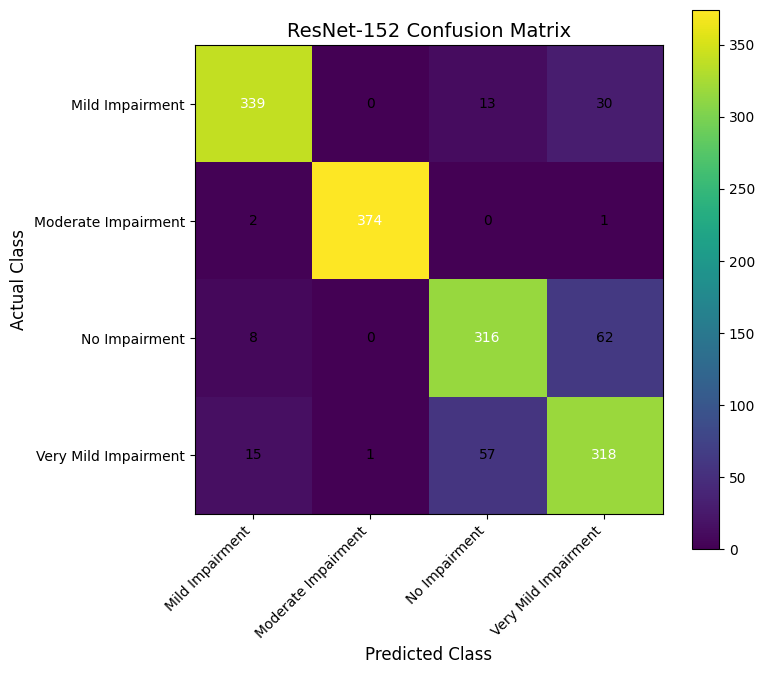

In [19]:
# ============================================
# CELL 10: CONFUSION MATRIX VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================
# 1. CREATE FIGURE
# ============================================

plt.figure(figsize=(8, 7))


# ============================================
# 2. DISPLAY CONFUSION MATRIX
# ============================================

plt.imshow(
    cm,
    interpolation="nearest"
)


# ============================================
# 3. TITLE
# ============================================

plt.title(
    "ResNet-152 Confusion Matrix",
    fontsize=14
)


# ============================================
# 4. COLORBAR
# ============================================

plt.colorbar()


# ============================================
# 5. CLASS LABELS
# ============================================

tick_marks = np.arange(
    len(class_names)
)

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)


# ============================================
# 6. WRITE VALUES INSIDE MATRIX
# ============================================

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            verticalalignment="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


# ============================================
# 7. AXIS LABELS
# ============================================

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)


# ============================================
# 8. LAYOUT
# ============================================

plt.tight_layout()

plt.show()

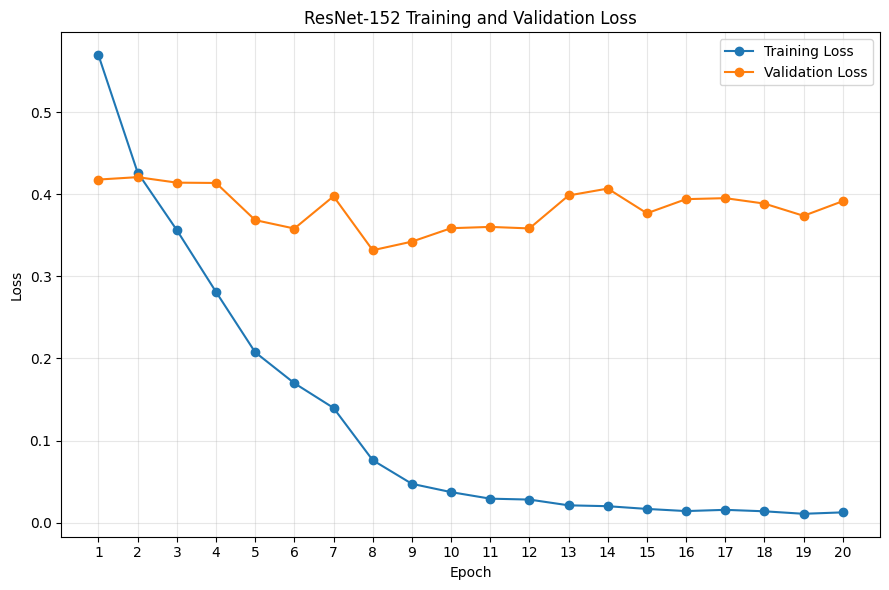

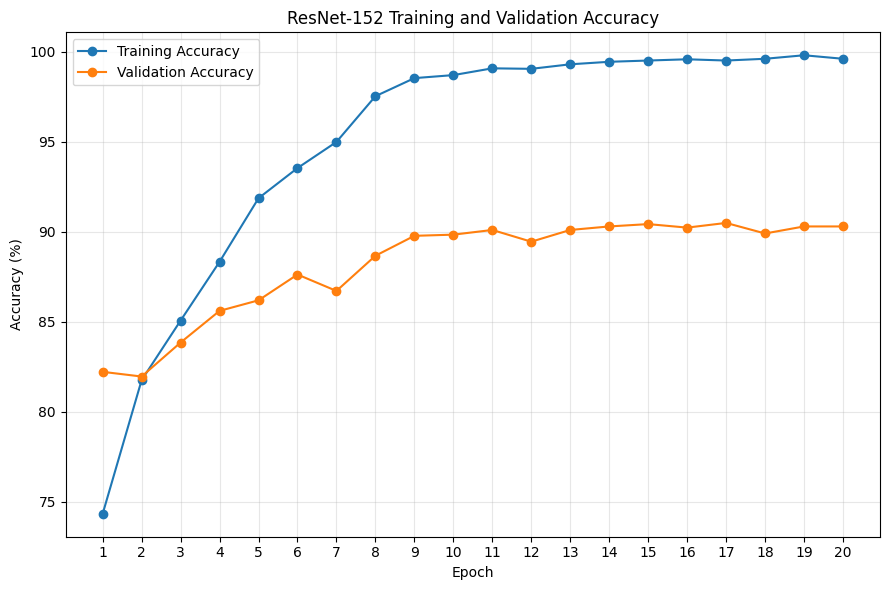

TRAINING HISTORY SUMMARY
Total epochs trained : 20
Best validation epoch: 17
Best validation acc. : 90.49%
Training acc. at best: 99.51%
Validation loss      : 0.3952
Learning rate        : 0.000010


In [20]:
# ============================================
# CELL 11: TRAINING & VALIDATION CURVES
# ============================================

import matplotlib.pyplot as plt


# ============================================
# 1. GET HISTORY
# ============================================

train_loss = history["train_loss"]
val_loss = history["val_loss"]

train_acc = history["train_acc"]
val_acc = history["val_acc"]

learning_rates = history["lr"]


# ============================================
# 2. CREATE EPOCH NUMBERS
# ============================================

epochs = range(
    1,
    len(train_loss) + 1
)


# ============================================
# 3. LOSS CURVE
# ============================================

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet-152 Training and Validation Loss"
)

plt.xticks(
    list(epochs)
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================
# 4. ACCURACY CURVE
# ============================================

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet-152 Training and Validation Accuracy"
)

plt.xticks(
    list(epochs)
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================
# 5. BEST VALIDATION EPOCH
# ============================================

best_epoch_index = max(
    range(len(val_acc)),
    key=lambda i: val_acc[i]
)

best_epoch = (
    best_epoch_index + 1
)

best_val_accuracy = (
    val_acc[best_epoch_index]
)


# ============================================
# 6. DISPLAY BEST EPOCH
# ============================================

print("=" * 60)
print("TRAINING HISTORY SUMMARY")
print("=" * 60)

print(
    f"Total epochs trained : "
    f"{len(train_loss)}"
)

print(
    f"Best validation epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation acc. : "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Training acc. at best: "
    f"{train_acc[best_epoch_index]:.2f}%"
)

print(
    f"Validation loss      : "
    f"{val_loss[best_epoch_index]:.4f}"
)

print(
    f"Learning rate        : "
    f"{learning_rates[best_epoch_index]:.6f}"
)

print("=" * 60)

In [21]:
# ============================================
# CELL 12: FINAL MODEL SUMMARY
# ============================================

print("=" * 70)
print("FINAL RESNET-152 MODEL SUMMARY")
print("=" * 70)


# ============================================
# MODEL INFORMATION
# ============================================

print("\nMODEL")
print("-" * 70)

print("Architecture       : ResNet-152")
print("Pretrained weights : ImageNet-1K V2")
print("Input size         : 224 x 224")
print("Number of classes  : 4")
print("Classifier         : Dropout(0.5) + Linear(2048 → 4)")
print("Device             : CUDA")


# ============================================
# DATASET INFORMATION
# ============================================

print("\nDATASET")
print("-" * 70)

print("Total images       : 10,240")
print("Training images    : 7,168")
print("Validation images  : 1,536")
print("Testing images     : 1,536")

print("\nClasses:")

for i, name in enumerate(class_names):
    print(f"  {i} → {name}")


# ============================================
# TRAINING CONFIGURATION
# ============================================

print("\nTRAINING CONFIGURATION")
print("-" * 70)

print("Batch size         : 16")
print("Epochs             : 20")
print("Optimizer          : Adam")
print("Initial LR         : 0.001")
print("Scheduler           : StepLR")
print("Step size          : 7")
print("Gamma              : 0.1")
print("Loss               : CrossEntropyLoss")


# ============================================
# TRAINING RESULTS
# ============================================

best_epoch_index = max(
    range(len(history["val_acc"])),
    key=lambda i: history["val_acc"][i]
)

best_epoch = best_epoch_index + 1

best_train_acc = history["train_acc"][best_epoch_index]
best_val_acc = history["val_acc"][best_epoch_index]

best_train_loss = history["train_loss"][best_epoch_index]
best_val_loss = history["val_loss"][best_epoch_index]


print("\nTRAINING RESULTS")
print("-" * 70)

print(
    f"Best epoch         : {best_epoch}"
)

print(
    f"Training accuracy  : {best_train_acc:.2f}%"
)

print(
    f"Validation accuracy: {best_val_acc:.2f}%"
)

print(
    f"Training loss      : {best_train_loss:.4f}"
)

print(
    f"Validation loss    : {best_val_loss:.4f}"
)


# ============================================
# TEST RESULTS
# ============================================

print("\nTEST RESULTS")
print("-" * 70)

print(
    f"Test loss          : {test_loss:.4f}"
)

print(
    f"Test accuracy      : {test_accuracy:.2f}%"
)

print(
    f"Correct predictions: {test_correct}/{test_total}"
)

print(
    f"Incorrect predictions: "
    f"{test_incorrect}/{test_total}"
)


# ============================================
# PARAMETER INFORMATION
# ============================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = (
    total_params - trainable_params
)


print("\nPARAMETERS")
print("-" * 70)

print(
    f"Total parameters   : {total_params:,}"
)

print(
    f"Trainable params   : {trainable_params:,}"
)

print(
    f"Frozen parameters  : {frozen_params:,}"
)


# ============================================
# CHECKPOINT
# ============================================

print("\nMODEL CHECKPOINT")
print("-" * 70)

print(
    BASE_PATH / "models" / "resnet152_best.pth"
)


# ============================================
# FINAL
# ============================================

print("\n" + "=" * 70)
print("✅ RESNET-152 EXPERIMENT COMPLETE")
print("=" * 70)

FINAL RESNET-152 MODEL SUMMARY

MODEL
----------------------------------------------------------------------
Architecture       : ResNet-152
Pretrained weights : ImageNet-1K V2
Input size         : 224 x 224
Number of classes  : 4
Classifier         : Dropout(0.5) + Linear(2048 → 4)
Device             : CUDA

DATASET
----------------------------------------------------------------------
Total images       : 10,240
Training images    : 7,168
Validation images  : 1,536
Testing images     : 1,536

Classes:
  0 → Mild Impairment
  1 → Moderate Impairment
  2 → No Impairment
  3 → Very Mild Impairment

TRAINING CONFIGURATION
----------------------------------------------------------------------
Batch size         : 16
Epochs             : 20
Optimizer          : Adam
Initial LR         : 0.001
Scheduler           : StepLR
Step size          : 7
Gamma              : 0.1
Loss               : CrossEntropyLoss

TRAINING RESULTS
-------------------------------------------------------------------